# 🚀 GPT-5.2 Models Evaluation on Microsoft Foundry

This notebook provides a comprehensive evaluation framework for the GPT-5.2 family of models:
- **GPT-5.2**: Full reasoning model with Chat Completions API and Responses API support
- **GPT-5.2-Chat**: Optimized chat model (Preview) with faster responses
- **GPT-5.2-Codex**: Specialized for code generation, optimized for Codex CLI & VS Code extension

> https://azure.microsoft.com/en-us/blog/introducing-gpt-5-2-in-microsoft-foundry-the-new-standard-for-enterprise-ai/?msockid=26142c154a3263a22e423a774b4a62ee 
 


## 1. Setup and Configuration

In [1]:
import asyncio
import json
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import sys
import time

from azure.identity import DefaultAzureCredential
from datetime import datetime
from dotenv import load_dotenv
from openai import OpenAI
from tabulate import tabulate
from tqdm import tqdm
from typing import Dict, List, Optional, Tuple

In [2]:
sys.version

'3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]'

In [3]:
print(f"Today is {datetime.today().strftime('%d-%b-%Y %H:%M:%S')}")

Today is 05-Feb-2026 16:07:28


## 1. Settings

In [4]:
load_dotenv("azure.env")

AZURE_OPENAI_ENDPOINT = os.getenv("AZURE_OPENAI_ENDPOINT", "")

In [5]:
# Model deployment names - Update these with your actual deployment names
MODELS = {
    "gpt-5.2": "gpt-5.2",           # Your GPT-5.2 deployment name
    "gpt-5.2-chat": "gpt-5.2-chat", # Your GPT-5.2-Chat deployment name
    "gpt-5.2-codex": "gpt-5.2-codex" # Your GPT-5.2-Codex deployment name
}

# Model capabilities reference
MODEL_CAPABILITIES = {
    "gpt-5.2": {
        "chat_completions": True,
        "responses_api": True,
        "reasoning": True,
        "structured_outputs": True,
        "image_input": True,
        "tools": True,
        "max_output": 128000,
        "context_window": 400000
    },
    "gpt-5.2-chat": {
        "chat_completions": True,
        "responses_api": True,
        "reasoning": True,
        "structured_outputs": True,
        "image_input": True,
        "tools": True,
        "max_output": 16384,
        "context_window": 128000
    },
    "gpt-5.2-codex": {
        "chat_completions": False,  # Responses API only
        "responses_api": True,
        "reasoning": True,
        "structured_outputs": True,
        "image_input": True,
        "tools": True,
        "max_output": 128000,
        "context_window": 400000
    }
}

print(f"🤖 Models to evaluate: {list(MODELS.keys())}")

🤖 Models to evaluate: ['gpt-5.2', 'gpt-5.2-chat', 'gpt-5.2-codex']


In [6]:
MODEL_CAPABILITIES

{'gpt-5.2': {'chat_completions': True,
  'responses_api': True,
  'reasoning': True,
  'structured_outputs': True,
  'image_input': True,
  'tools': True,
  'max_output': 128000,
  'context_window': 400000},
 'gpt-5.2-chat': {'chat_completions': True,
  'responses_api': True,
  'reasoning': True,
  'structured_outputs': True,
  'image_input': True,
  'tools': True,
  'max_output': 16384,
  'context_window': 128000},
 'gpt-5.2-codex': {'chat_completions': False,
  'responses_api': True,
  'reasoning': True,
  'structured_outputs': True,
  'image_input': True,
  'tools': True,
  'max_output': 128000,
  'context_window': 400000}}

In [7]:
# Authentication setup using DefaultAzureCredential (Entra ID)
credential = DefaultAzureCredential()

def get_token_with_scope(*args, **kwargs):
    """Get authentication token for Azure Cognitive Services."""
    return credential.get_token("https://cognitiveservices.azure.com/.default").token

client = OpenAI(
    base_url=f"{AZURE_OPENAI_ENDPOINT}/openai/v1/",
    api_key=get_token_with_scope
)

print("✅ Azure OpenAI client initialized with Entra ID authentication")

✅ Azure OpenAI client initialized with Entra ID authentication


## 2. Helper

In [8]:
class EvaluationResult:
    """Class to store evaluation results for a single test."""
    
    def __init__(self, model: str, task: str, prompt: str):
        self.model = model
        self.task = task
        self.prompt = prompt
        self.response = None
        self.latency_ms = 0
        self.input_tokens = 0
        self.output_tokens = 0
        self.reasoning_tokens = 0
        self.total_tokens = 0
        self.success = False
        self.error = None
        self.timestamp = datetime.now()
    
    def to_dict(self) -> Dict:
        return {
            "model": self.model,
            "task": self.task,
            "prompt": self.prompt[:100] + "..." if len(self.prompt) > 100 else self.prompt,
            "response": self.response[:200] + "..." if self.response and len(self.response) > 200 else self.response,
            "latency_ms": self.latency_ms,
            "input_tokens": self.input_tokens,
            "output_tokens": self.output_tokens,
            "reasoning_tokens": self.reasoning_tokens,
            "total_tokens": self.total_tokens,
            "success": self.success,
            "error": self.error,
            "timestamp": self.timestamp.isoformat()
        }

In [9]:
def call_chat_completions(
    model: str,
    messages: List[Dict],
    temperature: float = 0.7,
    max_completion_tokens: int = 4000,
    reasoning_effort: Optional[str] = None
) -> Tuple[str, Dict]:
    """
    Call the Chat Completions API.
    
    Args:
        model: Model deployment name
        messages: List of message dictionaries
        temperature: Sampling temperature (not supported for reasoning models with effort)
        max_completion_tokens: Maximum tokens to generate
        reasoning_effort: Reasoning effort level (minimal, low, medium, high)
    
    Returns:
        Tuple of (response_text, usage_dict)
    """
    kwargs = {
        "model": model,
        "messages": messages,
        "max_completion_tokens": max_completion_tokens
    }
    
    if reasoning_effort:
        kwargs["reasoning_effort"] = reasoning_effort
    else:
        kwargs["temperature"] = temperature
    
    response = client.chat.completions.create(**kwargs)
    
    usage = {
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "reasoning_tokens": getattr(
            response.usage.completion_tokens_details, 
            "reasoning_tokens", 
            0
        ) if response.usage.completion_tokens_details else 0
    }
    
    return response.choices[0].message.content, usage

In [10]:
def call_responses_api(
    model: str,
    input_text: str,
    reasoning_effort: str = "medium",
    reasoning_summary: str = "auto"
) -> Tuple[str, Dict, Optional[str]]:
    """
    Call the Responses API (required for gpt-5.2-codex).
    
    Args:
        model: Model deployment name
        input_text: Input text/prompt
        reasoning_effort: Reasoning effort level (minimal, low, medium, high)
        reasoning_summary: Summary verbosity (auto, concise, detailed)
    
    Returns:
        Tuple of (response_text, usage_dict, reasoning_summary_text)
    """
    response = client.responses.create(
        model=model,
        input=input_text,
        reasoning={
            "effort": reasoning_effort,
            "summary": reasoning_summary
        }
    )
    
    # Extract response text and reasoning summary
    response_text = ""
    reasoning_summary_text = None
    
    for item in response.output:
        if item.type == "message":
            for content in item.content:
                if content.type == "output_text":
                    response_text = content.text
        elif item.type == "reasoning":
            if hasattr(item, 'summary') and item.summary:
                reasoning_summary_text = str(item.summary)
    
    usage = {
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "total_tokens": response.usage.total_tokens,
        "reasoning_tokens": getattr(
            response.usage.output_tokens_details,
            "reasoning_tokens",
            0
        ) if response.usage.output_tokens_details else 0
    }
    
    return response_text, usage, reasoning_summary_text

In [11]:
def run_evaluation(
    model: str,
    task: str,
    prompt: str,
    use_responses_api: bool = False,
    reasoning_effort: Optional[str] = None,
    **kwargs
) -> EvaluationResult:
    """
    Run a single evaluation test.
    
    Args:
        model: Model deployment name
        task: Task category name
        prompt: The prompt to send
        use_responses_api: Whether to use Responses API instead of Chat Completions
        reasoning_effort: Reasoning effort level
        **kwargs: Additional arguments
    
    Returns:
        EvaluationResult object
    """
    result = EvaluationResult(model, task, prompt)
    
    try:
        start_time = time.time()
        
        if use_responses_api:
            response_text, usage, _ = call_responses_api(
                model=model,
                input_text=prompt,
                reasoning_effort=reasoning_effort or "medium"
            )
        else:
            messages = [
                {"role": "system", "content": kwargs.get("system_prompt", "You are a helpful assistant.")},
                {"role": "user", "content": prompt}
            ]
            response_text, usage = call_chat_completions(
                model=model,
                messages=messages,
                reasoning_effort=reasoning_effort
            )
        
        end_time = time.time()
        
        result.response = response_text
        result.latency_ms = (end_time - start_time) * 1000
        result.input_tokens = usage["input_tokens"]
        result.output_tokens = usage["output_tokens"]
        result.reasoning_tokens = usage["reasoning_tokens"]
        result.total_tokens = usage["total_tokens"]
        result.success = True
        
    except Exception as e:
        result.error = str(e)
        result.success = False
    
    return result

## 3. Evaluation Test Cases

In [12]:
EVALUATION_TESTS = {
    "general_knowledge": [
        "Explain the theory of relativity in simple terms.",
        "What are the main differences between supervised and unsupervised machine learning?",
        "Describe the process of photosynthesis."
    ],
    
    "reasoning": [
        "A farmer has 17 sheep. All but 9 run away. How many sheep does the farmer have left?",
        "If it takes 5 machines 5 minutes to make 5 widgets, how long would it take 100 machines to make 100 widgets?",
        "Three friends check into a hotel room that costs $30. They each contribute $10. Later, the manager realizes the room was only $25 and gives $5 to the bellboy to return. The bellboy keeps $2 and gives $1 back to each friend. Now each friend paid $9 (total $27) plus the bellboy kept $2 = $29. Where is the missing dollar?"
    ],
    
    "code_generation": [
        "Write a Python function to implement binary search on a sorted list.",
        "Create a Python class for a thread-safe singleton pattern.",
        "Write a Python function that validates if a string is a valid IPv4 address."
    ],
    
    "code_debugging": [
        """Debug this Python code that should find the second largest number in a list:
```python
def second_largest(nums):
    largest = max(nums)
    nums.remove(largest)
    return max(nums)
```
What are the potential issues and how would you fix them?""",
        
        """This async Python code has a race condition. Identify and fix it:
```python
import asyncio

counter = 0

async def increment():
    global counter
    temp = counter
    await asyncio.sleep(0.001)
    counter = temp + 1

async def main():
    await asyncio.gather(*[increment() for _ in range(100)])
    print(f"Counter: {counter}")
```"""
    ],
    
    "code_optimization": [
        """Optimize this O(n²) Python function to find duplicates:
```python
def find_duplicates(arr):
    duplicates = []
    for i in range(len(arr)):
        for j in range(i + 1, len(arr)):
            if arr[i] == arr[j] and arr[i] not in duplicates:
                duplicates.append(arr[i])
    return duplicates
```"""
    ],
    
    "summarization": [
        """Summarize the following text in 2-3 sentences:
        
Artificial intelligence (AI) has rapidly evolved from a niche research topic to a transformative technology 
affecting virtually every industry. Machine learning, a subset of AI, enables computers to learn from data 
without being explicitly programmed. Deep learning, which uses neural networks with many layers, has achieved 
remarkable results in image recognition, natural language processing, and game playing. However, challenges 
remain, including the need for large amounts of labeled training data, the difficulty of explaining AI decisions, 
and concerns about bias and fairness. As AI continues to advance, it promises to automate routine tasks, 
accelerate scientific discovery, and create new opportunities for human-AI collaboration."""
    ],
    
    "creative_writing": [
        "Write a short poem (4-8 lines) about the beauty of mathematics.",
        "Create a brief story opening (2-3 sentences) for a science fiction novel set on Mars."
    ],
    
    "data_analysis": [
        """Given this sales data, identify trends and provide insights:
Q1 2024: $1.2M, Q2 2024: $1.5M, Q3 2024: $1.3M, Q4 2024: $1.8M
Q1 2025: $1.6M, Q2 2025: $1.9M, Q3 2025: $1.7M, Q4 2025: $2.2M"""
    ],
    
    "math_problem": [
        "Solve: What is the derivative of f(x) = x³ + 2x² - 5x + 3?",
        "Calculate the probability of getting exactly 3 heads when flipping a fair coin 5 times."
    ]
}

print(f"📋 Total test categories: {len(EVALUATION_TESTS)}")
print(f"📝 Total test cases: {sum(len(tests) for tests in EVALUATION_TESTS.values())}")

📋 Total test categories: 9
📝 Total test cases: 18


## 4. Run Evaluation

In [13]:
def run_full_evaluation(
    models_to_test: List[str] = None,
    tasks_to_test: List[str] = None,
    reasoning_effort: str = "medium"
) -> pd.DataFrame:
    """
    Run the full evaluation suite across specified models and tasks.
    
    Args:
        models_to_test: List of model names to test (default: all)
        tasks_to_test: List of task categories to test (default: all)
        reasoning_effort: Reasoning effort level for reasoning models
    
    Returns:
        DataFrame with all evaluation results
    """
    if models_to_test is None:
        models_to_test = list(MODELS.keys())
    
    if tasks_to_test is None:
        tasks_to_test = list(EVALUATION_TESTS.keys())
    
    results = []
    
    total_tests = sum(
        len(EVALUATION_TESTS[task]) 
        for task in tasks_to_test
    ) * len(models_to_test)
    
    print(f"\n🔬 Starting evaluation of {len(models_to_test)} models across {len(tasks_to_test)} task categories")
    print(f"📊 Total tests to run: {total_tests}\n")
    
    with tqdm(total=total_tests, desc="Running evaluations") as pbar:
        for model_name in models_to_test:
            model_deployment = MODELS[model_name]
            capabilities = MODEL_CAPABILITIES[model_name]
            
            # Determine which API to use
            use_responses_api = not capabilities["chat_completions"]
            
            for task in tasks_to_test:
                for prompt in EVALUATION_TESTS[task]:
                    result = run_evaluation(
                        model=model_deployment,
                        task=task,
                        prompt=prompt,
                        use_responses_api=use_responses_api,
                        reasoning_effort=reasoning_effort
                    )
                    result.model = model_name  # Use friendly name
                    results.append(result.to_dict())
                    pbar.update(1)
                    
                    # Small delay to avoid rate limiting
                    time.sleep(0.5)
    
    df = pd.DataFrame(results)
    print(f"\n✅ Evaluation complete! {len(df)} results collected.")
    
    return df

In [14]:
results_df = run_full_evaluation(
    models_to_test=["gpt-5.2", "gpt-5.2-chat", "gpt-5.2-codex"],
    reasoning_effort="medium"
)


🔬 Starting evaluation of 3 models across 9 task categories
📊 Total tests to run: 54



Running evaluations: 100%|██████████| 54/54 [05:43<00:00,  6.36s/it]


✅ Evaluation complete! 54 results collected.


In [24]:
results_df

,model,task,prompt,response,latency_ms,input_tokens,output_tokens,reasoning_tokens,total_tokens,success,error,timestamp
0,gpt-5.2,general_knowledge,Explain the theory of relativity in simple terms.,Einstein’s theory of relativity is really two ...,13185.386896,26,511,0,537,True,None,2026-02-05T16:07:32.600981
1,gpt-5.2,general_knowledge,What are the main differences between supervis...,**Supervised learning vs. unsupervised learnin...,8193.339825,30,341,0,371,True,None,2026-02-05T16:07:46.288383
2,gpt-5.2,general_knowledge,Describe the process of photosynthesis.,"Photosynthesis is the process plants, algae, a...",8983.272552,23,434,0,457,True,None,2026-02-05T16:07:54.983691
3,gpt-5.2,reasoning,A farmer has 17 sheep. All but 9 run away. How...,“All but 9” means **everything except 9** ran ...,1077.393293,39,29,0,68,True,None,2026-02-05T16:08:04.468906
4,gpt-5.2,reasoning,If it takes 5 machines 5 minutes to make 5 wid...,5 minutes.\n\nBecause 5 machines make 5 widget...,2424.192905,45,93,41,138,True,None,2026-02-05T16:08:06.048196
5,gpt-5.2,reasoning,Three friends check into a hotel room that cos...,No dollar is missing—the $27 is being added to...,9774.692059,99,228,39,327,True,None,2026-02-05T16:08:08.974255
6,gpt-5.2,code_generation,Write a Python function to implement binary se...,"```python\ndef binary_search(arr, target):\n ...",3247.838259,29,179,0,208,True,None,2026-02-05T16:08:19.250899
7,gpt-5.2,code_generation,Create a Python class for a thread-safe single...,```python\nimport threading\n\n\nclass Singlet...,3148.942947,27,195,27,222,True,None,2026-02-05T16:08:23.000551
8,gpt-5.2,code_generation,Write a Python function that validates if a st...,```python\nimport re\n\ndef is_valid_ipv4(s: s...,3875.992060,32,165,0,197,True,None,2026-02-05T16:08:26.651475
9,gpt-5.2,code_debugging,Debug this Python code that should find the se...,Potential issues in that implementation:\n\n1....,20485.892534,71,713,184,784,True,None,2026-02-05T16:08:31.029297


## 5. Results Analysis

In [15]:
def display_summary_statistics(df: pd.DataFrame):
    """Display summary statistics for the evaluation results."""
    
    print("\n" + "="*80)
    print("📊 EVALUATION SUMMARY STATISTICS")
    print("="*80)
    
    # Success rate by model
    success_by_model = df.groupby('model')['success'].mean() * 100
    print("\n✅ Success Rate by Model:")
    for model, rate in success_by_model.items():
        print(f"   {model}: {rate:.1f}%")
    
    # Filter to successful results only
    success_df = df[df['success'] == True]
    
    # Average latency by model
    print("\n⏱️ Average Latency (ms) by Model:")
    latency_stats = success_df.groupby('model')['latency_ms'].agg(['mean', 'std', 'min', 'max'])
    print(tabulate(latency_stats.round(2), headers='keys', tablefmt='pretty'))
    
    # Token usage by model
    print("\n🔤 Average Token Usage by Model:")
    token_stats = success_df.groupby('model')[['input_tokens', 'output_tokens', 'reasoning_tokens', 'total_tokens']].mean()
    print(tabulate(token_stats.round(0), headers='keys', tablefmt='pretty'))
    
    # Performance by task category
    print("\n📋 Average Latency by Task Category:")
    task_latency = success_df.groupby('task')['latency_ms'].mean().sort_values(ascending=False)
    for task, latency in task_latency.items():
        print(f"   {task}: {latency:.0f}ms")

display_summary_statistics(results_df)


📊 EVALUATION SUMMARY STATISTICS

✅ Success Rate by Model:
   gpt-5.2: 100.0%
   gpt-5.2-chat: 100.0%
   gpt-5.2-codex: 100.0%

⏱️ Average Latency (ms) by Model:
+---------------+---------+---------+---------+----------+
|     model     |  mean   |   std   |   min   |   max    |
+---------------+---------+---------+---------+----------+
|    gpt-5.2    | 6489.26 | 5601.29 | 1077.39 | 20485.89 |
| gpt-5.2-chat  | 5374.44 | 2937.91 | 2008.97 | 10931.14 |
| gpt-5.2-codex | 5707.82 | 3253.89 | 3296.1  | 16167.48 |
+---------------+---------+---------+---------+----------+

🔤 Average Token Usage by Model:
+---------------+--------------+---------------+------------------+--------------+
|     model     | input_tokens | output_tokens | reasoning_tokens | total_tokens |
+---------------+--------------+---------------+------------------+--------------+
|    gpt-5.2    |     58.0     |     246.0     |       19.0       |    304.0     |
| gpt-5.2-chat  |     58.0     |     279.0     |       0.0  

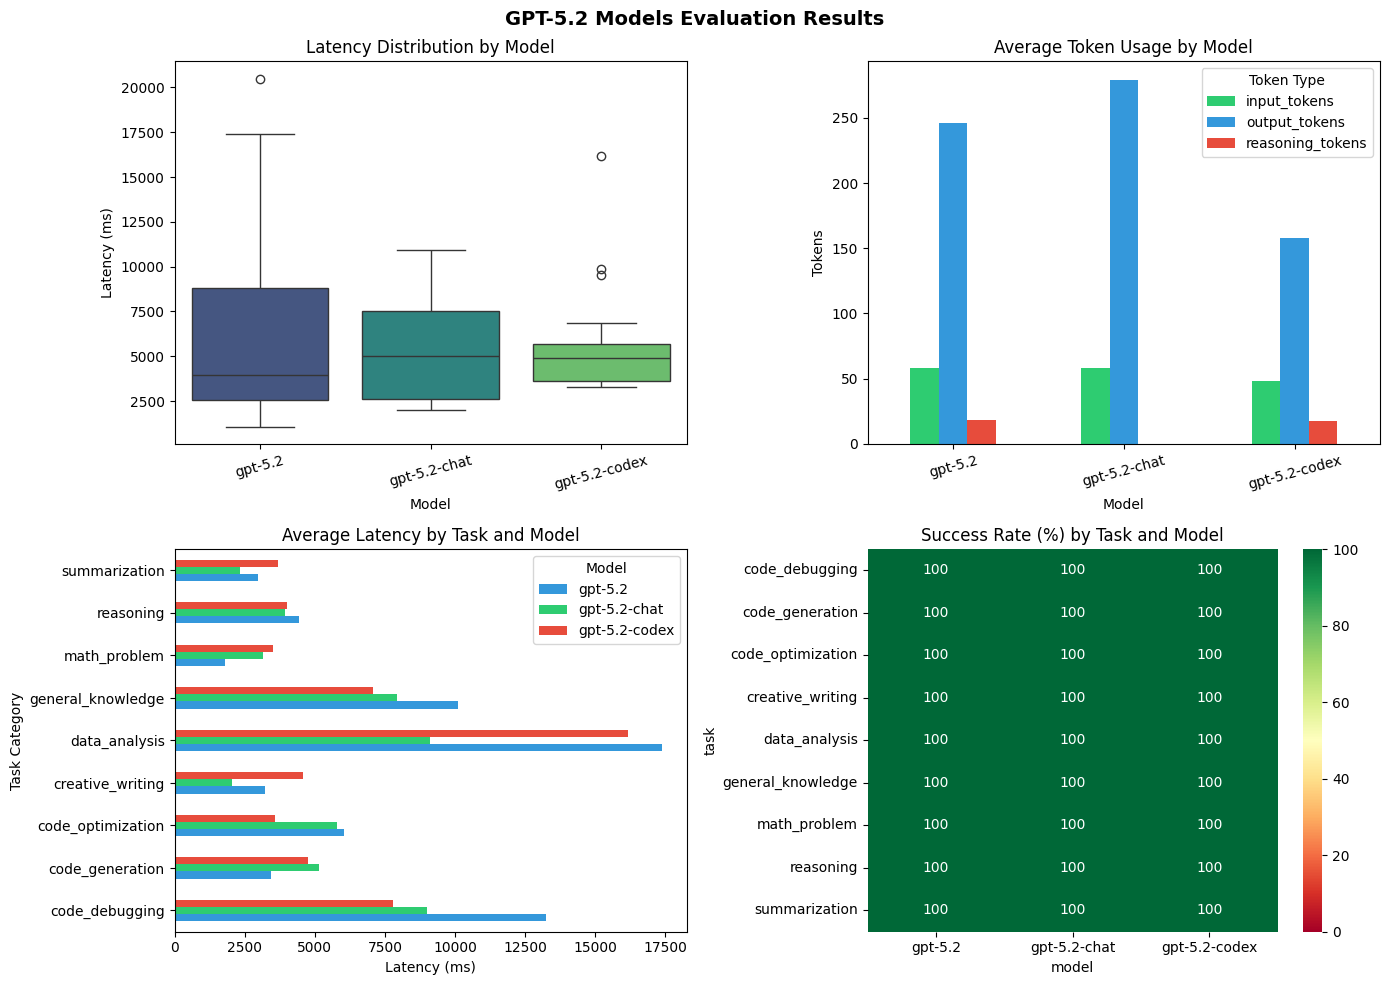


📈 Visualizations saved to 'gpt52_evaluation_results.png'


In [16]:
def create_visualizations(df: pd.DataFrame):
    """Create visualization plots for evaluation results."""
    
    success_df = df[df['success'] == True]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('GPT-5.2 Models Evaluation Results', fontsize=14, fontweight='bold')
    
    # Plot 1: Latency comparison by model
    ax1 = axes[0, 0]
    sns.boxplot(data=success_df, x='model', y='latency_ms', ax=ax1, hue='model', palette='viridis')
    ax1.set_title('Latency Distribution by Model')
    ax1.set_xlabel('Model')
    ax1.set_ylabel('Latency (ms)')
    ax1.tick_params(axis='x', rotation=15)
    
    # Plot 2: Token usage comparison
    ax2 = axes[0, 1]
    token_data = success_df.groupby('model')[['input_tokens', 'output_tokens', 'reasoning_tokens']].mean()
    token_data.plot(kind='bar', ax=ax2, color=['#2ecc71', '#3498db', '#e74c3c'])
    ax2.set_title('Average Token Usage by Model')
    ax2.set_xlabel('Model')
    ax2.set_ylabel('Tokens')
    ax2.tick_params(axis='x', rotation=15)
    ax2.legend(title='Token Type')
    
    # Plot 3: Latency by task category
    ax3 = axes[1, 0]
    task_model_latency = success_df.pivot_table(
        values='latency_ms', 
        index='task', 
        columns='model', 
        aggfunc='mean'
    )
    task_model_latency.plot(kind='barh', ax=ax3, color=['#3498db', '#2ecc71', '#e74c3c'])
    ax3.set_title('Average Latency by Task and Model')
    ax3.set_xlabel('Latency (ms)')
    ax3.set_ylabel('Task Category')
    ax3.legend(title='Model')
    
    # Plot 4: Success rate heatmap
    ax4 = axes[1, 1]
    success_pivot = df.pivot_table(
        values='success', 
        index='task', 
        columns='model', 
        aggfunc='mean'
    ) * 100
    sns.heatmap(
        success_pivot, 
        annot=True, 
        fmt='.0f', 
        cmap='RdYlGn', 
        ax=ax4,
        vmin=0, 
        vmax=100
    )
    ax4.set_title('Success Rate (%) by Task and Model')
    
    plt.tight_layout()
    plt.savefig('gpt52_evaluation_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n📈 Visualizations saved to 'gpt52_evaluation_results.png'")

create_visualizations(results_df)

## 6. Detailed Results by Model

In [17]:
def display_model_comparison(df: pd.DataFrame):
    """Display detailed comparison between models."""
    
    success_df = df[df['success'] == True]
    
    print("\n" + "="*80)
    print("🤖 DETAILED MODEL COMPARISON")
    print("="*80)
    
    comparison_data = []
    
    for model in df['model'].unique():
        model_df = success_df[success_df['model'] == model]
        
        if len(model_df) == 0:
            continue
            
        comparison_data.append({
            'Model': model,
            'Avg Latency (ms)': f"{model_df['latency_ms'].mean():.0f}",
            'P50 Latency (ms)': f"{model_df['latency_ms'].median():.0f}",
            'P95 Latency (ms)': f"{model_df['latency_ms'].quantile(0.95):.0f}",
            'Avg Output Tokens': f"{model_df['output_tokens'].mean():.0f}",
            'Avg Reasoning Tokens': f"{model_df['reasoning_tokens'].mean():.0f}",
            'Total Tests': len(df[df['model'] == model]),
            'Success Rate': f"{(len(model_df) / len(df[df['model'] == model])) * 100:.1f}%"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + tabulate(comparison_df, headers='keys', tablefmt='pretty', showindex=False))

display_model_comparison(results_df)


🤖 DETAILED MODEL COMPARISON

+---------------+------------------+------------------+------------------+-------------------+----------------------+-------------+--------------+
|     Model     | Avg Latency (ms) | P50 Latency (ms) | P95 Latency (ms) | Avg Output Tokens | Avg Reasoning Tokens | Total Tests | Success Rate |
+---------------+------------------+------------------+------------------+-------------------+----------------------+-------------+--------------+
|    gpt-5.2    |       6489       |       3939       |      17856       |        246        |          19          |     18      |    100.0%    |
| gpt-5.2-chat  |       5374       |       5014       |       9667       |        279        |          0           |     18      |    100.0%    |
| gpt-5.2-codex |       5708       |       4911       |      10831       |        158        |          18          |     18      |    100.0%    |
+---------------+------------------+------------------+------------------+--------------

## 7. Sample Responses Comparison

In [18]:
def display_sample_responses(df: pd.DataFrame, task: str = "code_generation", max_chars: int = 500):
    """Display sample responses from each model for a specific task."""
    
    print(f"\n{'='*80}")
    print(f"📝 SAMPLE RESPONSES - Task: {task}")
    print(f"{'='*80}")
    
    task_df = df[(df['task'] == task) & (df['success'] == True)]
    
    if len(task_df) == 0:
        print(f"No successful results for task: {task}")
        return
    
    # Get first prompt for this task
    first_prompt = task_df.iloc[0]['prompt']
    print(f"\n📌 Prompt: {first_prompt[:200]}..." if len(first_prompt) > 200 else f"\n📌 Prompt: {first_prompt}")
    
    for model in df['model'].unique():
        model_response = task_df[task_df['model'] == model]
        
        if len(model_response) > 0:
            response = model_response.iloc[0]['response']
            latency = model_response.iloc[0]['latency_ms']
            
            print(f"\n{'─'*40}")
            print(f"🤖 {model} (Latency: {latency:.0f}ms)")
            print(f"{'─'*40}")
            
            if response:
                display_response = response[:max_chars] + "..." if len(response) > max_chars else response
                print(display_response)

# Display sample responses for code generation task
display_sample_responses(results_df, task="code_generation")


📝 SAMPLE RESPONSES - Task: code_generation

📌 Prompt: Write a Python function to implement binary search on a sorted list.

────────────────────────────────────────
🤖 gpt-5.2 (Latency: 3248ms)
────────────────────────────────────────
```python
def binary_search(arr, target):
    """
    Return the index of `target` in sorted list `arr`, or -1 if not found.
    Assumes `arr` is sorted in ascending order.
    """
    lo, hi = 0, len...

────────────────────────────────────────
🤖 gpt-5.2-chat (Latency: 2918ms)
────────────────────────────────────────
Here’s a simple and clear implementation of binary search in Python. This version returns the index of the target if found, or `-1` if it is not present.

```python
def binary_search(arr, target):
   ...

────────────────────────────────────────
🤖 gpt-5.2-codex (Latency: 4236ms)
────────────────────────────────────────
```python
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
    

In [19]:
# Display sample responses for reasoning task
display_sample_responses(results_df, task="reasoning")


📝 SAMPLE RESPONSES - Task: reasoning

📌 Prompt: A farmer has 17 sheep. All but 9 run away. How many sheep does the farmer have left?

────────────────────────────────────────
🤖 gpt-5.2 (Latency: 1077ms)
────────────────────────────────────────
“All but 9” means **everything except 9** ran away, so the farmer has **9 sheep** left.

────────────────────────────────────────
🤖 gpt-5.2-chat (Latency: 3075ms)
────────────────────────────────────────
The farmer has **9 sheep** left.

“All but 9 run away” means **all except 9** ran away.

────────────────────────────────────────
🤖 gpt-5.2-codex (Latency: 3296ms)
────────────────────────────────────────
9 sheep remain.


## 8. Export Results

In [20]:
# Export results to CSV and JSON
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# CSV export
csv_filename = f'gpt52_evaluation_results_{timestamp}.csv'
results_df.to_csv(csv_filename, index=False)
print(f"📁 Results exported to: {csv_filename}")

# JSON export with full responses
json_filename = f'gpt52_evaluation_results_{timestamp}.json'
results_df.to_json(json_filename, orient='records', indent=2)
print(f"📁 Results exported to: {json_filename}")

📁 Results exported to: gpt52_evaluation_results_20260205_161317.csv
📁 Results exported to: gpt52_evaluation_results_20260205_161317.json


## 9. Specialized Tests: GPT-5.2-Codex with Responses API

In [21]:
def test_codex_advanced_features():
    """
    Test advanced features specific to GPT-5.2-Codex using the Responses API.
    """
    print("\n" + "="*80)
    print("🔧 GPT-5.2-CODEX ADVANCED FEATURES TEST")
    print("="*80)
    
    # Test 1: Code generation with reasoning summary
    print("\n📝 Test 1: Code generation with reasoning summary")
    print("-"*40)
    
    try:
        response_text, usage, reasoning_summary = call_responses_api(
            model=MODELS["gpt-5.2-codex"],
            input_text="Write an efficient Python implementation of merge sort with detailed comments.",
            reasoning_effort="high",
            reasoning_summary="detailed"
        )
        
        print(f"✅ Success!")
        print(f"📊 Tokens - Input: {usage['input_tokens']}, Output: {usage['output_tokens']}, Reasoning: {usage['reasoning_tokens']}")
        print(f"\n💭 Reasoning Summary: {reasoning_summary[:300] if reasoning_summary else 'Not available'}...")
        print(f"\n📝 Response (truncated):\n{response_text[:500]}...")
        
    except Exception as e:
        print(f"❌ Error: {e}")
    
    # Test 2: Complex code refactoring
    print("\n📝 Test 2: Complex code refactoring")
    print("-"*40)
    
    complex_code_prompt = """
    Refactor this Python code to be more efficient and follow best practices:
    
    ```python
    def process_data(data):
        result = []
        for i in range(len(data)):
            if data[i] != None:
                temp = data[i] * 2
                if temp > 10:
                    result.append(temp)
        return result
    ```
    
    Provide the refactored code with explanations.
    """
    
    try:
        response_text, usage, _ = call_responses_api(
            model=MODELS["gpt-5.2-codex"],
            input_text=complex_code_prompt,
            reasoning_effort="medium"
        )
        
        print(f"✅ Success!")
        print(f"📊 Tokens - Input: {usage['input_tokens']}, Output: {usage['output_tokens']}")
        print(f"\n📝 Response (truncated):\n{response_text[:600]}...")
        
    except Exception as e:
        print(f"❌ Error: {e}")

# Run the advanced Codex tests
test_codex_advanced_features()


🔧 GPT-5.2-CODEX ADVANCED FEATURES TEST

📝 Test 1: Code generation with reasoning summary
----------------------------------------
✅ Success!
📊 Tokens - Input: 18, Output: 1130, Reasoning: 576

💭 Reasoning Summary: [Summary(text='**Crafting Python merge sort**\n\nI need to write an efficient Python implementation of merge sort with detailed comments. The user wants the merge_sort function and the merge function, using recursion and list slicing. However, I want to avoid slicing to enhance efficiency, maybe usi...

📝 Response (truncated):
Below is an efficient, **stable** merge sort implementation in Python.  
It sorts the list *in place* using a single auxiliary buffer to avoid repeated allocations.  
Detailed comments explain each step.

```python
def merge_sort(arr):
    """
    Sorts `arr` in-place using merge sort.
    Time complexity: O(n log n)
    Extra space:     O(n) for the auxiliary buffer
    """
    n = len(arr)
    if n <= 1:
        return arr  # already sorted

    # Au

## 10. Reasoning Effort Comparison

In [22]:
def compare_reasoning_efforts():
    """
    Compare different reasoning effort levels on the same prompt.
    """
    print("\n" + "="*80)
    print("🧠 REASONING EFFORT COMPARISON")
    print("="*80)
    
    test_prompt = "Solve this step by step: If a train travels at 60 mph for 2 hours, then 80 mph for 1.5 hours, what is the total distance and average speed?"
    
    effort_levels = ["minimal", "low", "medium", "high"]
    
    results = []
    
    print(f"\n📌 Test Prompt: {test_prompt}\n")
    
    for effort in effort_levels:
        print(f"\nTesting reasoning_effort = '{effort}'...")
        
        try:
            start_time = time.time()
            
            messages = [
                {"role": "system", "content": "You are a helpful math tutor. Show your work."},
                {"role": "user", "content": test_prompt}
            ]
            
            response_text, usage = call_chat_completions(
                model=MODELS["gpt-5.2"],
                messages=messages,
                reasoning_effort=effort,
                max_completion_tokens=2000
            )
            
            latency = (time.time() - start_time) * 1000
            
            results.append({
                'Effort': effort,
                'Latency (ms)': f"{latency:.0f}",
                'Output Tokens': usage['output_tokens'],
                'Reasoning Tokens': usage['reasoning_tokens'],
                'Total Tokens': usage['total_tokens']
            })
            
            print(f"  ✅ Latency: {latency:.0f}ms, Reasoning Tokens: {usage['reasoning_tokens']}")
            
        except Exception as e:
            print(f"  ❌ Error: {e}")
            results.append({
                'Effort': effort,
                'Latency (ms)': 'Error',
                'Output Tokens': '-',
                'Reasoning Tokens': '-',
                'Total Tokens': '-'
            })
        
        time.sleep(1)  # Rate limiting
    
    print("\n📊 Reasoning Effort Comparison Results:")
    print(tabulate(results, headers='keys', tablefmt='pretty'))

# Run reasoning effort comparison
compare_reasoning_efforts()


🧠 REASONING EFFORT COMPARISON

📌 Test Prompt: Solve this step by step: If a train travels at 60 mph for 2 hours, then 80 mph for 1.5 hours, what is the total distance and average speed?


Testing reasoning_effort = 'minimal'...
  ✅ Latency: 2850ms, Reasoning Tokens: 0

Testing reasoning_effort = 'low'...
  ✅ Latency: 3969ms, Reasoning Tokens: 0

Testing reasoning_effort = 'medium'...
  ✅ Latency: 3357ms, Reasoning Tokens: 0

Testing reasoning_effort = 'high'...
  ✅ Latency: 4514ms, Reasoning Tokens: 82

📊 Reasoning Effort Comparison Results:
+---------+--------------+---------------+------------------+--------------+
| Effort  | Latency (ms) | Output Tokens | Reasoning Tokens | Total Tokens |
+---------+--------------+---------------+------------------+--------------+
| minimal |     2850     |      213      |        0         |     273      |
|   low   |     3969     |      343      |        0         |     403      |
| medium  |     3357     |      268      |        0         |     

## 11. Summary and Recommendations

In [23]:
def print_summary_recommendations(df: pd.DataFrame):
    """Print summary and recommendations based on evaluation results."""
    
    print("\n" + "="*80)
    print("📋 SUMMARY AND RECOMMENDATIONS")
    print("="*80)
    
    success_df = df[df['success'] == True]
    
    # Find best performing model for each metric
    if len(success_df) > 0:
        fastest_model = success_df.groupby('model')['latency_ms'].mean().idxmin()
        most_efficient = success_df.groupby('model')['total_tokens'].mean().idxmin()
        
        print("\n🏆 Performance Highlights:")
        print(f"   • Fastest average response: {fastest_model}")
        print(f"   • Most token-efficient: {most_efficient}")
    
    print("\n💡 Model Selection Guidelines:")
    print("""
    ┌─────────────────────────────────────────────────────────────────────────────┐
    │ Use Case                              │ Recommended Model                   │
    ├─────────────────────────────────────────────────────────────────────────────┤
    │ Complex reasoning & analysis          │ gpt-5.2 (with high reasoning_effort)│
    │ Fast conversational responses         │ gpt-5.2-chat                        │
    │ Code generation & debugging           │ gpt-5.2-codex                       │
    │ Cost-sensitive applications           │ gpt-5.2-chat (smaller context)      │
    │ Long document processing              │ gpt-5.2 or gpt-5.2-codex (400K ctx) │
    │ Codex CLI / VS Code integration       │ gpt-5.2-codex (optimized for this)  │
    └─────────────────────────────────────────────────────────────────────────────┘
    """)
    
    print("\n⚙️ API Recommendations:")
    print("""
    • gpt-5.2 & gpt-5.2-chat: Support both Chat Completions API and Responses API
    • gpt-5.2-codex: Use Responses API only (Chat Completions not supported)
    • For reasoning tasks: Set reasoning_effort based on complexity
      - 'minimal'/'low': Quick responses, simple tasks
      - 'medium': Balanced performance (recommended default)
      - 'high': Complex reasoning, math, code analysis
    """)
    
    print("\n📚 Resources:")
    print("   • Azure OpenAI Reasoning Models: https://learn.microsoft.com/azure/ai-foundry/openai/how-to/reasoning")
    print("   • Responses API Guide: https://learn.microsoft.com/azure/ai-foundry/openai/how-to/responses")
    print("   • Codex CLI Setup: https://learn.microsoft.com/azure/ai-foundry/openai/how-to/codex")

print_summary_recommendations(results_df)


📋 SUMMARY AND RECOMMENDATIONS

🏆 Performance Highlights:
   • Fastest average response: gpt-5.2-chat
   • Most token-efficient: gpt-5.2-codex

💡 Model Selection Guidelines:

    ┌─────────────────────────────────────────────────────────────────────────────┐
    │ Use Case                              │ Recommended Model                   │
    ├─────────────────────────────────────────────────────────────────────────────┤
    │ Complex reasoning & analysis          │ gpt-5.2 (with high reasoning_effort)│
    │ Fast conversational responses         │ gpt-5.2-chat                        │
    │ Code generation & debugging           │ gpt-5.2-codex                       │
    │ Cost-sensitive applications           │ gpt-5.2-chat (smaller context)      │
    │ Long document processing              │ gpt-5.2 or gpt-5.2-codex (400K ctx) │
    │ Codex CLI / VS Code integration       │ gpt-5.2-codex (optimized for this)  │
    └────────────────────────────────────────────────────────────────